In [16]:
import odc.stac
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import planetary_computer
import pystac_client
import xarray as xr
from pystac.extensions.eo import EOExtension as eo

# Viz
import hvplot.xarray
import panel as pn

pn.extension()

from dask.distributed import Client, LocalCluster
from odc.stac import configure_rio, stac_load

### Part 1

1. Connect to the Planetary Computer STAC catalog using `pystac-client`.

In [17]:
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

catalog.title

'Microsoft Planetary Computer STAC API'

2. Find the Landsat Collection 2 Level-2 dataset. Per [Project Pythia](https://projectpythia.org/landsat-ml-cookbook/notebooks/data-ingestion-geospatial/):
> We’ll use the `landsat-c2-l2` dataset, which stands for Collection 2 Level-2. It contains data from several landsat missions and has better data quality than Level 1 (`landsat-c2-l1`). Microsoft Planetary Computer has descriptions of [Level 1](https://planetarycomputer.microsoft.com/dataset/landsat-c2-l1) and [Level 2](https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2), but a direct and succinct comparison can be found in [this community post](https://gis.stackexchange.com/questions/439767/landsat-collections), and the information can be verified with [USGS](https://www.usgs.gov/landsat-missions/landsat-collection-2).

In [18]:
all_collections = [i.id for i in catalog.get_collections()]
landsat_collections = [
    collection for collection in all_collections if "landsat" in collection
]
landsat_collections

['landsat-c2-l2', 'landsat-c2-l1']

3. Explore the metadata by simply examining the collection object. What's the description? STAC version? Check out the links, the ID, the license, keywords, etc. List the assets available in this collection. What bands are available? What other assets (e.g., QA bands, thumbnails) are included?

In [19]:
collection = landsat_collections[0]
landsat_c2_l2 = catalog.get_collection(collection)
landsat_c2_l2

<CollectionClient id=landsat-c2-l2>

The description explains that this is Landsat Collection 2 Level-2, and the sort of data that it contains. The STAC version is 1.1.0.

### Part 2

4. Define a bounding box for Singapore. Hint: we deliberately chose Singapore because it's small enough to fit within a single Landsat tile; this simplifies loading.

In [20]:
bbox = [103.594894, 1.234519, 104.101639, 1.481967]
datetime = "2024-01-01/2024-12-30"
platform = "landsat-8"
cloudy_less_than = 50

5. Set up a Dask cluster for parallel processing. Use `odc.stac.configure_rio(cloud_defaults=True, client=client)` to configure `rasterio` for efficient cloud COG access. This step is critical—without it, loading data from the cloud will be extremely slow.

In [ ]:
cluster = LocalCluster(
    processes=True,
    n_workers=8,
    threads_per_worker=2,
    memory_limit="6GB",
)
client = Client(cluster)
configure_rio(cloud_defaults=True, client=client)

/Users/sujankakumanu/Documents/musa-650-spring2026/.venv/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 60458 instead
  warnings.warn(


2026-02-28 07:15:43,939 - distributed.scheduler - WARNING - Worker failed to heartbeat for 955s; attempting restart: <WorkerState 'tcp://127.0.0.1:60478', name: 7, status: running, memory: 0, processing: 0>
2026-02-28 07:15:44,072 - distributed.scheduler - WARNING - Worker failed to heartbeat for 955s; attempting restart: <WorkerState 'tcp://127.0.0.1:60479', name: 3, status: running, memory: 0, processing: 0>
2026-02-28 07:15:44,073 - distributed.scheduler - WARNING - Worker failed to heartbeat for 955s; attempting restart: <WorkerState 'tcp://127.0.0.1:60480', name: 6, status: running, memory: 0, processing: 0>
2026-02-28 07:15:44,073 - distributed.scheduler - WARNING - Worker failed to heartbeat for 955s; attempting restart: <WorkerState 'tcp://127.0.0.1:60481', name: 5, status: running, memory: 0, processing: 0>
2026-02-28 07:15:44,073 - distributed.scheduler - WARNING - Worker failed to heartbeat for 955s; attempting restart: <WorkerState 'tcp://127.0.0.1:60482', name: 1, status: 

6. Search for Landsat scenes within your bounding box for 2025. Filter for scenes with less than 50% cloud cover. (Singapore is cloudy; you may need to adjust this threshold to get enough scenes.)

In [22]:
search = catalog.search(
    collections=[collection],
    bbox=bbox,
    datetime=datetime,
    query={"eo:cloud_cover": {"lt": cloudy_less_than}, "platform": {"in": [platform]}},
)
items = search.item_collection()
print(f"Returned {len(items)} Items:")
item_id = {(i, item.id): i for i, item in enumerate(items)}
item_id

Returned 8 Items:


{(0, 'LC08_L2SP_125059_20241218_02_T2'): 0,
 (1, 'LC08_L2SP_125059_20240812_02_T1'): 1,
 (2, 'LC08_L2SP_125059_20240625_02_T1'): 2,
 (3, 'LC08_L2SP_125059_20240609_02_T1'): 3,
 (4, 'LC08_L2SP_125059_20240422_02_T1'): 4,
 (5, 'LC08_L2SP_125059_20240406_02_T1'): 5,
 (6, 'LC08_L2SP_125059_20240218_02_T1'): 6,
 (7, 'LC08_L2SP_125059_20240202_02_T1'): 7}

7. Preview your results. How many scenes did you get? Look at some thumbnails to verify you're getting what you expect.

In [23]:
item_sel = pn.widgets.Select(value=1, options=item_id, name="item")

def get_preview(i):
    return pn.panel(items[i].assets["rendered_preview"].href, height=300)


pn.Row(item_sel, pn.bind(get_preview, item_sel))

BokehModel(combine_events=True, render_bundle={'docs_json': {'5cdcd4ea-184c-436d-b013-b31a12e278b5': {'version…

8. Visualize the STAC item footprints on a map. Do the tiles cover your entire bounding box? Are there gaps?

In [24]:
df = gpd.GeoDataFrame.from_features(items.to_dict(), crs="epsg:4326")

bbox_geom = box(*bbox)
bbox_gdf = gpd.GeoDataFrame([{"geometry": bbox_geom}], crs="epsg:4326")

m = df[["geometry", "datetime", "eo:cloud_cover"]].explore(
    column="eo:cloud_cover", style_kwds={"fillOpacity": 0.1}
)

bbox_gdf.explore(
    m=m, style_kwds={"color": "red", "weight": 4, "fillOpacity": 0}, name="Bounding Box"
)

m

9. Create a time series plot showing cloud cover percentage per scene across the year.

<Axes: title={'center': 'eo:cloud-cover'}, xlabel='datetime'>

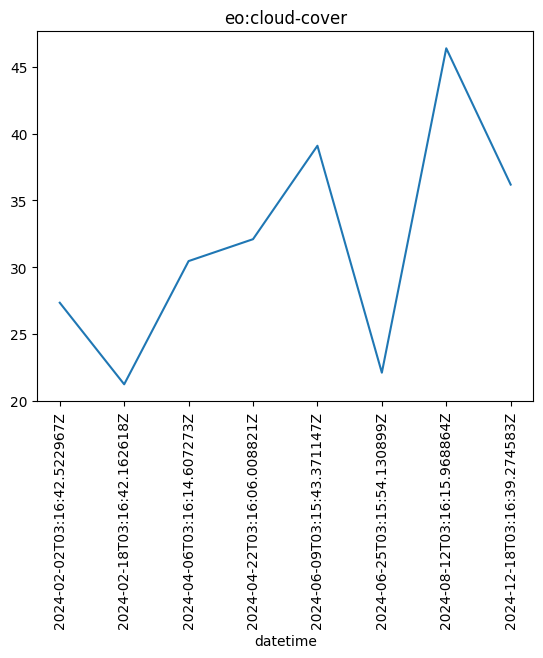

In [25]:
ts = df.set_index("datetime").sort_index()["eo:cloud_cover"]
ts.plot(title="eo:cloud-cover", rot=90)

### Part 3

10. Load the data using `odc.stac.load`. Include the spectral bands (red, green, blue, nir08) and qa_pixel for cloud masking. Experiment with different resolutions and chunk sizes to get the data to load efficiently. A couple of hints:
 - We deliberately selected Singapore to avoid the need to load multiple tiles to cover the AOI.
 - Landsat data is 30m resolution. You _can_ coarsen this to load more quickly, but if you optimize your chunking, you should be able to load all of your data at 30m resolution in a couple of minutes.
 - If you get _really_ stuck, feel free to look at the solutions notebook.

In [26]:
bands_of_interest = ["red", "green", "blue", "nir08", "qa_pixel"]

data = stac_load(
    items,
    bands=bands_of_interest,
    crs="EPSG:3857",
    resolution=30,
    chunks={"time": -1, "x": 128, "y": 128},
    bbox=bbox,
)

11. Examine the resulting dataset. What are its dimensions? What's the CRS? How much data would you be loading if you called `.compute()` right now?

In [27]:
data

<xarray.Dataset> Size: 138MB
Dimensions:      (y: 919, x: 1881, time: 8)
Coordinates:
  * y            (y) float64 7kB 1.65e+05 1.65e+05 ... 1.375e+05 1.374e+05
  * x            (x) float64 15kB 1.153e+07 1.153e+07 ... 1.159e+07 1.159e+07
  * time         (time) datetime64[ns] 64B 2024-02-02T03:16:42.522967 ... 202...
    spatial_ref  int32 4B 3857
Data variables:
    red          (time, y, x) uint16 28MB dask.array<chunksize=(8, 128, 128), meta=np.ndarray>
    green        (time, y, x) uint16 28MB dask.array<chunksize=(8, 128, 128), meta=np.ndarray>
    blue         (time, y, x) uint16 28MB dask.array<chunksize=(8, 128, 128), meta=np.ndarray>
    nir08        (time, y, x) uint16 28MB dask.array<chunksize=(8, 128, 128), meta=np.ndarray>
    qa_pixel     (time, y, x) uint16 28MB dask.array<chunksize=(8, 128, 128), meta=np.ndarray>

In [28]:
# FROM SOLUTIONS SHEET. Answering question from above.
total_bytes = sum(data[var].nbytes for var in data.data_vars)
print(f"Total size: {total_bytes / 1e9:.2f} GB ({total_bytes / 1e6:.2f} MB)")

Total size: 0.14 GB (138.29 MB)


12. Create a cloud mask using the `qa_pixel` band. Bits 3 and 4 indicate cloud and cloud shadow respectively. Mask out cloudy pixels so they become NaN.

In [29]:
cloud_mask = (data["qa_pixel"] & 0b11000) == 0

data_masked = data[["nir08", "red", "green", "blue"]].where(cloud_mask)

median = data_masked.median(dim="time")
result = median.compute()

Aborting load due to failure while reading: https://landsateuwest.blob.core.windows.net/landsat-c2/level-2/standard/oli-tirs/2024/125/059/LC08_L2SP_125059_20240202_20240208_02_T1/LC08_L2SP_125059_20240202_20240208_02_T1_QA_PIXEL.TIF:1
Aborting load due to failure while reading: https://landsateuwest.blob.core.windows.net/landsat-c2/level-2/standard/oli-tirs/2024/125/059/LC08_L2SP_125059_20240202_20240208_02_T1/LC08_L2SP_125059_20240202_20240208_02_T1_QA_PIXEL.TIF:1
Aborting load due to failure while reading: https://landsateuwest.blob.core.windows.net/landsat-c2/level-2/standard/oli-tirs/2024/125/059/LC08_L2SP_125059_20240202_20240208_02_T1/LC08_L2SP_125059_20240202_20240208_02_T1_QA_PIXEL.TIF:1
Aborting load due to failure while reading: https://landsateuwest.blob.core.windows.net/landsat-c2/level-2/standard/oli-tirs/2024/125/059/LC08_L2SP_125059_20240202_20240208_02_T1/LC08_L2SP_125059_20240202_20240208_02_T1_SR_B3.TIF:1
Aborting load due to failure while reading: https://landsateuwe

Exception: RasterioIOError('HTTP response code: 409')


13. Create a median composite across all time steps. Because cloudy pixels are NaN, the median will ignore them and select from clear observations only. Call `.compute()` to trigger the actual download and computation.